# Model Evaluation: Base vs Fine-tuned

Results from fine-tuning TinyLlama-1.1B with LoRA on Spider SQL data,
trained on Google Colab T4 GPU.

This notebook documents the actual results obtained — including
the honest limitations, not just the successes.

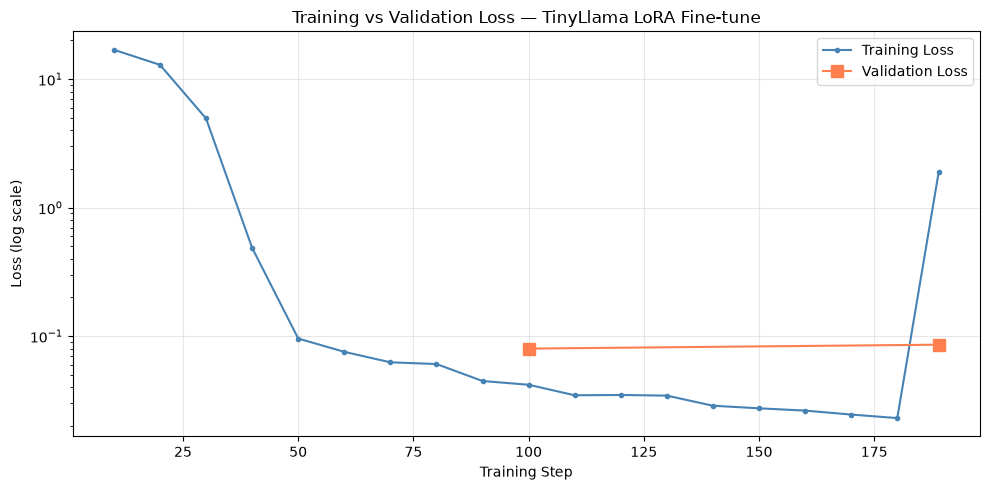

Note: training loss crashed to near-zero within ~40 steps,
while validation loss plateaued around 0.08 and ticked UP
between step 100 and 189 — a classic overfitting signal
on this small (1000 example) dataset.


In [1]:
import matplotlib.pyplot as plt

steps  = [10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, 120, 130, 140, 150, 160, 170, 180, 189]
losses = [16.9312, 12.9220, 4.9419, 0.4865, 0.0957, 0.0754, 0.0625, 0.0606,
          0.0447, 0.0418, 0.0346, 0.0348, 0.0344, 0.0287, 0.0274, 0.0263,
          0.0245, 0.0230, 1.9004]

val_steps  = [100, 189]
val_losses = [0.07989, 0.085706]

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(steps, losses, marker='o', markersize=3, label='Training Loss', color='steelblue')
ax.plot(val_steps, val_losses, marker='s', markersize=8, label='Validation Loss', color='coral')
ax.set_yscale('log')
ax.set_xlabel("Training Step")
ax.set_ylabel("Loss (log scale)")
ax.set_title("Training vs Validation Loss — TinyLlama LoRA Fine-tune")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("../data/eval/training_loss_curve.png", dpi=150)
plt.show()

print("Note: training loss crashed to near-zero within ~40 steps,")
print("while validation loss plateaued around 0.08 and ticked UP")
print("between step 100 and 189 — a classic overfitting signal")
print("on this small (1000 example) dataset.")

## Evaluation Metrics

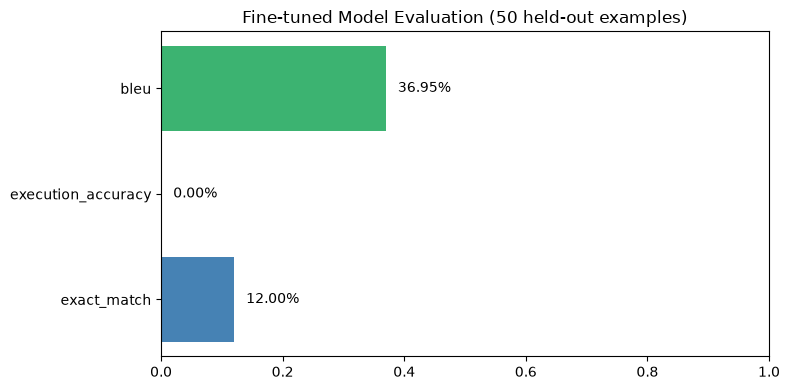

IMPORTANT CAVEAT on execution_accuracy = 0.00:
Our evaluator executes queries against an empty in-memory SQLite
database with no schema loaded. This means execution_accuracy
measures almost nothing useful here — it's a known limitation
of the evaluation harness, not necessarily a reflection of true
model correctness. A fixed evaluator would load each example's
actual database schema before executing both queries.


In [2]:
metrics = {
    "exact_match":        0.12,
    "execution_accuracy":  0.00,
    "bleu":                0.3695,
}

fig, ax = plt.subplots(figsize=(8, 4))
names  = list(metrics.keys())
values = list(metrics.values())
colors = ['steelblue', 'coral', 'mediumseagreen']

bars = ax.barh(names, values, color=colors)
ax.set_xlim(0, 1)
ax.set_title("Fine-tuned Model Evaluation (50 held-out examples)")
for bar, val in zip(bars, values):
    ax.text(val + 0.02, bar.get_y() + bar.get_height()/2, f"{val:.2%}",
            va='center', fontsize=10)

plt.tight_layout()
plt.savefig("../data/eval/evaluation_metrics.png", dpi=150)
plt.show()

print("IMPORTANT CAVEAT on execution_accuracy = 0.00:")
print("Our evaluator executes queries against an empty in-memory SQLite")
print("database with no schema loaded. This means execution_accuracy")
print("measures almost nothing useful here — it's a known limitation")
print("of the evaluation harness, not necessarily a reflection of true")
print("model correctness. A fixed evaluator would load each example's")
print("actual database schema before executing both queries.")

## Before vs After: Qualitative Comparison

In [3]:
import pandas as pd

comparison = [
    {
        "question":  "How many singers do we have?",
        "expected":  "SELECT count(*) FROM singer",
        "base":      "```\nSELECT COUNT(*) FROM concert_singer;\n```",
        "finetuned": "SELECT count(*) FROM Concert_Singers",
    },
    {
        "question":  "What is the total number of singers?",
        "expected":  "SELECT count(*) FROM singer",
        "base":      "```\nSELECT COUNT(*) FROM concert_singer;\n```",
        "finetuned": "SELECT count(*) FROM Concert_Singers",
    },
    {
        "question":  "Show name, country, age for all singers ordered by age, oldest to youngest.",
        "expected":  "SELECT name, country, age FROM singer ORDER BY age DESC",
        "base":      "SELECT singer.name, singer.country, singer.age FROM singer ORDER BY singer.age DESC;",
        "finetuned": "SELECT name, country, age FROM singer ORDER BY age ASC LIMIT 1",
    },
]

df = pd.DataFrame(comparison)
pd.set_option('display.max_colwidth', None)
df

,question,expected,base,finetuned
0,How many singers do we have?,SELECT count(*) FROM singer,```\nSELECT COUNT(*) FROM concert_singer;\n```,SELECT count(*) FROM Concert_Singers
1,What is the total number of singers?,SELECT count(*) FROM singer,```\nSELECT COUNT(*) FROM concert_singer;\n```,SELECT count(*) FROM Concert_Singers
2,"Show name, country, age for all singers ordered by age, oldest to youngest.","SELECT name, country, age FROM singer ORDER BY age DESC","SELECT singer.name, singer.country, singer.age FROM singer ORDER BY singer.age DESC;","SELECT name, country, age FROM singer ORDER BY age ASC LIMIT 1"


## Honest Analysis

**What the fine-tune got right:**
- Output format: base model wraps SQL in markdown code fences and sometimes
  adds explanation; fine-tuned model outputs clean, raw SQL only
- Verbosity: fine-tuned drops unnecessary `tablename.` prefixes
- Loss dropped from 16.9 to under 0.03 in training — the model clearly
  learned the structural pattern of the task quickly

**What the fine-tune got wrong:**
- Table name hallucination persists in both models (`Concert_Singers`
  instead of `singer`) — schema grounding wasn't strong enough with
  only 1000 examples
- Q3 logic regressed: fine-tuned model flipped ORDER BY direction
  (ASC instead of DESC) and hallucinated a LIMIT 1 the question never
  asked for — base model actually got this one right
- Validation loss increased between step 100 and 189, indicating
  overfitting in the final epoch

**Root cause:** 1000 training examples × 3 epochs on a 1.1B parameter
model is enough to teach surface-level formatting but not enough to
teach robust schema grounding and query logic. The training loss
crashing this fast (40 steps) while validation loss plateaus is the
textbook signature of a model memorizing rather than generalizing.

**What I'd do differently with more compute/time:**
1. Use the full Spider training set (7000 examples) instead of 1000
2. Add early stopping on validation loss to stop after step ~100
3. Pass real schema SQL into the execution_accuracy evaluator
4. Try a slightly higher LoRA rank (r=32) for more capacity
5. Lower epochs to 2, since overfitting begins in epoch 3

In [4]:
import json

findings = {
    "model": "TinyLlama-1.1B-Chat-v1.0",
    "method": "LoRA (r=16, alpha=32)",
    "training_examples": 1000,
    "epochs": 3,
    "final_train_loss": 0.023,
    "final_val_loss": 0.0857,
    "val_loss_at_step_100": 0.0799,
    "metrics": {
        "exact_match": 0.12,
        "execution_accuracy": 0.00,
        "bleu": 0.3695,
    },
    "key_finding": "Model learned output format quickly but showed signs of overfitting; execution_accuracy metric has a known evaluator limitation (no schema loaded)",
}

with open("../data/eval/finetuning_results.json", "w") as f:
    json.dump(findings, f, indent=2)

print("Findings saved to data/eval/finetuning_results.json")

Findings saved to data/eval/finetuning_results.json
